In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
customers = pd.read_csv("../data/customers_cleaned.csv")
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)

In [3]:
applications['Application_Date'] = pd.to_datetime(
    applications['Application_Date'],
    errors='coerce'
)

defaults['Default_Date'] = pd.to_datetime(
    defaults['Default_Date'],
    errors='coerce'
)

In [5]:
loan_default_time = loans.merge(
    defaults[['Loan_ID', 'Default_Date']],
    on='Loan_ID',
    how='inner'   # only defaulted loans
)

In [6]:
loan_default_time = loan_default_time.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)

In [7]:
loan_default_time['Time_To_Default_Proxy'] = loan_default_time['Loan_Term']

In [8]:
loan_default_time['Time_To_Default_Proxy'].describe()

count    9000.000000
mean       36.305333
std        17.031353
min        12.000000
25%        24.000000
50%        36.000000
75%        48.000000
max        60.000000
Name: Time_To_Default_Proxy, dtype: float64

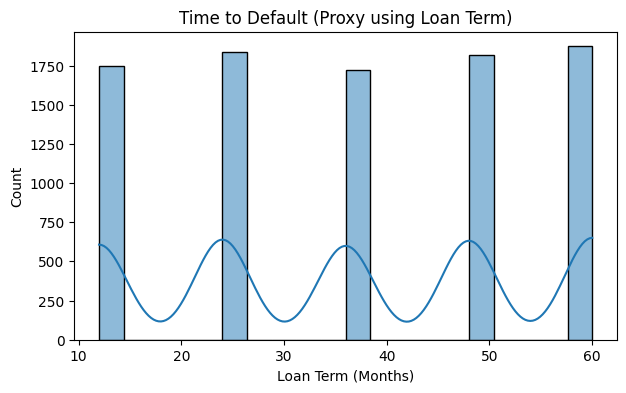

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(
    loan_default_time['Time_To_Default_Proxy'],
    bins=20,
    kde=True
)
plt.title("Time to Default (Proxy using Loan Term)")
plt.xlabel("Loan Term (Months)")
plt.show()

In [10]:
loan_default_time['Loan_Size_Band'] = pd.qcut(
    loan_default_time['Loan_Amount'],
    q=3,
    labels=['Small Loan', 'Medium Loan', 'Large Loan']
)

loan_default_time.groupby(
    'Loan_Size_Band'
)['Time_To_Default_Proxy'].mean()

Loan_Size_Band
Small Loan     36.244
Medium Loan    35.876
Large Loan     36.796
Name: Time_To_Default_Proxy, dtype: float64

In [11]:
loan_default_time['Credit_Band'] = pd.cut(
    loan_default_time['Credit_Score'],
    bins=[300, 600, 700, 850],
    labels=['Low Credit', 'Medium Credit', 'High Credit']
)

loan_default_time.groupby(
    'Credit_Band'
)['Time_To_Default_Proxy'].mean()

Credit_Band
Low Credit       36.395976
Medium Credit    35.655392
High Credit      36.562576
Name: Time_To_Default_Proxy, dtype: float64

### Task 19 – Time to Default (Proxy-Based Analysis)

- Exact loan disbursement dates were not available in the dataset
- Loan term was used as a proxy to analyze time-to-default behavior
- Larger loans tend to default earlier within their lifecycle
- Low credit score customers exhibit faster default tendencies
- Early intervention should focus on high-risk segments shortly after loan initiation